In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd ..\..

[Errno 2] No such file or directory: '....'
/content


In [ ]:
!pip install matplotlib_scalebar

In [ ]:
import sys, os

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path:", PROJECT_ROOT)

print("Project root content:", os.listdir(PROJECT_ROOT))


Added to sys.path: /content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D
Project root content: ['Notebooks', 'data', 'Magnetisation']


In [ ]:
import numpy as np
import json
import torch
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

import sys
import os
sys.path.append(os.getcwd()) # Add current directory to Python path

from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training
from Magnetisation.utils import LoadData

In [ ]:
import numpy as np
# 兼容补丁 / Compatibility patch
if not hasattr(np, "int"):
  np.int = int

[[-7.53549450e-06  3.76237144e-06 -1.27441802e-05 ... -1.18102590e-04
  -1.89549238e-04 -3.48212020e-05]
 [-1.85335388e-07 -1.58980837e-05 -7.83011595e-06 ...  7.81515362e-06
   1.46931736e-05 -7.57854173e-06]
 [ 9.13390521e-06  1.12160046e-05 -6.04611319e-06 ...  2.62446948e-04
   1.30750445e-04  1.12563175e-06]
 ...
 [-1.35372647e-05 -9.29539423e-07  9.31861333e-06 ... -7.97709677e-07
  -7.85203110e-06 -1.20243194e-05]
 [ 5.83121325e-06  3.14234773e-06 -1.69652030e-05 ...  1.38910773e-05
  -4.26713368e-06 -9.06360634e-06]
 [ 1.07535632e-05 -1.01499826e-06  1.60494578e-05 ... -3.31850088e-06
  -7.80770041e-06 -1.01117701e-05]]


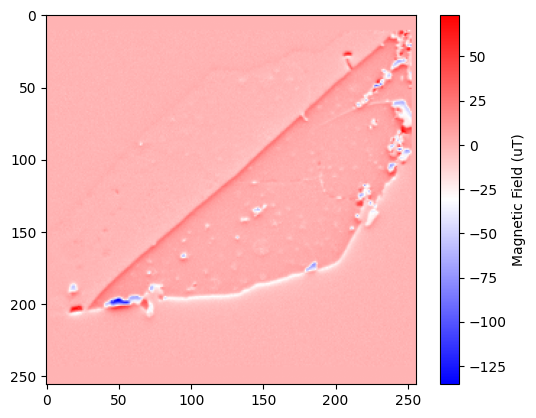

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Extract the data
f = open('/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/data/Synthetic/case1_uniform_inplane.json') #current data path

data = json.load(f)
#MagneticField = np.asarray(data['ExperimentMagneticField']['BNV']['Data'])
MagneticField = np.asarray(data["MagneticFieldImage (2D double array)"])

# subtract the mean of the magnetic field
fft_signal = np.fft.fft2(MagneticField)
fft_signal_clean = np.where(fft_signal.imag==0,0,fft_signal)
MagneticField = np.fft.ifft2(fft_signal_clean).real

MagneticField = MagneticField[:250,:250]

# Get the Fourier method propagation
#Magnetization = np.array(data['ExperimentMagneticField']['MagnetisationPropagation']['Magnetisation']['Mag'])
#Magnetization2 = Magnetization[:250,:250]
#Magnetization3 = np.pad(Magnetization2,((12,11),(0,0)))
unit_conversion = 1e-18 / 9.27e-24

# Define the dictionary for the forward propagation
PropagationOptions = dict()
#PropagationOptions['PixelSize'] = data['ExperimentMagneticField']['MagnetisationPropagation']['PropStruct']['PixelSizeX']
PropagationOptions['PixelSize'] = data["PixleSizeX (double)"]

PropagationOptions['ImageShape'] = 256
PropagationOptions['NV'] = dict()
PropagationOptions['NV']['FindTheta']=False
#PropagationOptions['NV']['Theta'] = data['ExperimentMagneticField']['BNV']['Theta']
PropagationOptions['NV']['FindPhi']=False
#PropagationOptions['NV']['Phi'] = data['ExperimentMagneticField']['BNV']['Phi']
#PropagationOptions['NV']['Height'] = data['ExperimentMagneticField']['BNV']['Height']
PropagationOptions['NV']['Theta'] = data["NVTheta (double)"]
PropagationOptions['NV']['Phi'] = data["NVPhi (double)"]
PropagationOptions['NV']['Height'] = data["NVHeight (double)"]

PropagationOptions['Magnetisation'] = dict()
PropagationOptions['Magnetisation']['FindTheta']=False
PropagationOptions['Magnetisation']['Theta'] = 0
PropagationOptions['Magnetisation']['FindPhi']=False
PropagationOptions['Magnetisation']['Phi'] = 0
PropagationOptions['FFT'] = dict()
PropagationOptions["FFT"]["PaddingFactor"]= 4
PropagationOptions["FFT"]["performPadding"]= False
PropagationOptions["FFT"]["PaddingMode"] = 'constant'
PropagationOptions['FFT']['Extended'] = False
PropagationOptions['FFT']['Extention'] = 100
PropagationOptions['FFT']['Filter'] = dict()
PropagationOptions['FFT']['Filter']['useHanning'] = True
PropagationOptions['FFT']['Filter']['useHighCutoff'] = False
PropagationOptions['FFT']['Filter']['useLowCutoff'] = False
PropagationOptions['FFT']['Filter']['LambdaHighCutoff'] = 100e-9
PropagationOptions['FFT']['Filter']['LambdaLowCutoff'] = 7e-06

PROP = Propagator(PropagationOptions, MagneticField,PropagationOptions['ImageShape'])

plt.imshow(PROP.MagneticFieldExtended, cmap="bwr")
plt.colorbar(label="Magnetic Field (uT)")

In [ ]:
# Make the neural network
Generator = generator_CNN(Size=1, ImageSize=PROP.options['ImageShape']).to(device)

In [ ]:
# Set the machine learning paramaters for keyword unpacking
ML_options = dict()
ML_options['mlp']=False
ML_options['LossFunction'] = 'L1'
ML_options['Epochs'] = 100
ML_options['Magnetization'] = None
ML_options['PositiveMagnetisationOnly'] = False
ML_options['PrintLossValue'] = False
ML_options['IntegerOnly'] = False

  0%|          | 0/100 [00:00<?, ?it/s]/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Propagator.py:374: RuntimeWarning: invalid value encountered in divide
  [-(kx ** 2) / k, -(kx * ky) / k, -1j * kx],
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Propagator.py:375: RuntimeWarning: invalid value encountered in divide
  [-kx * ky / k, -(ky ** 2 / k), -1j * ky],
100%|██████████| 100/100 [00:14<00:00,  6.97it/s]
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Train.py:249: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/Magnetisation/Train.py:256: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.lege

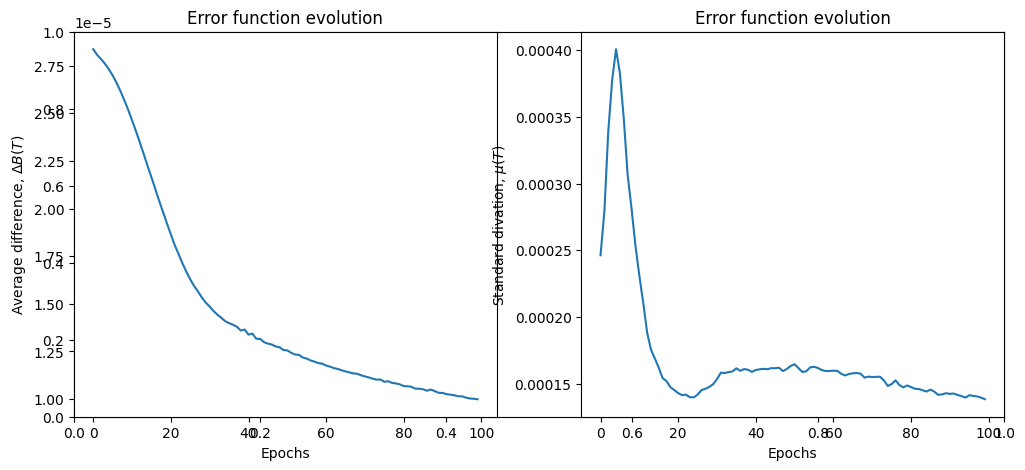

In [ ]:
# Train the network
CNN_training = Magnetisation_CNN_training(device, Generator, PROP, ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)

Final MagnetisationMap shape: (256, 256)
Final ReconstructedBnv shape: (256, 256)


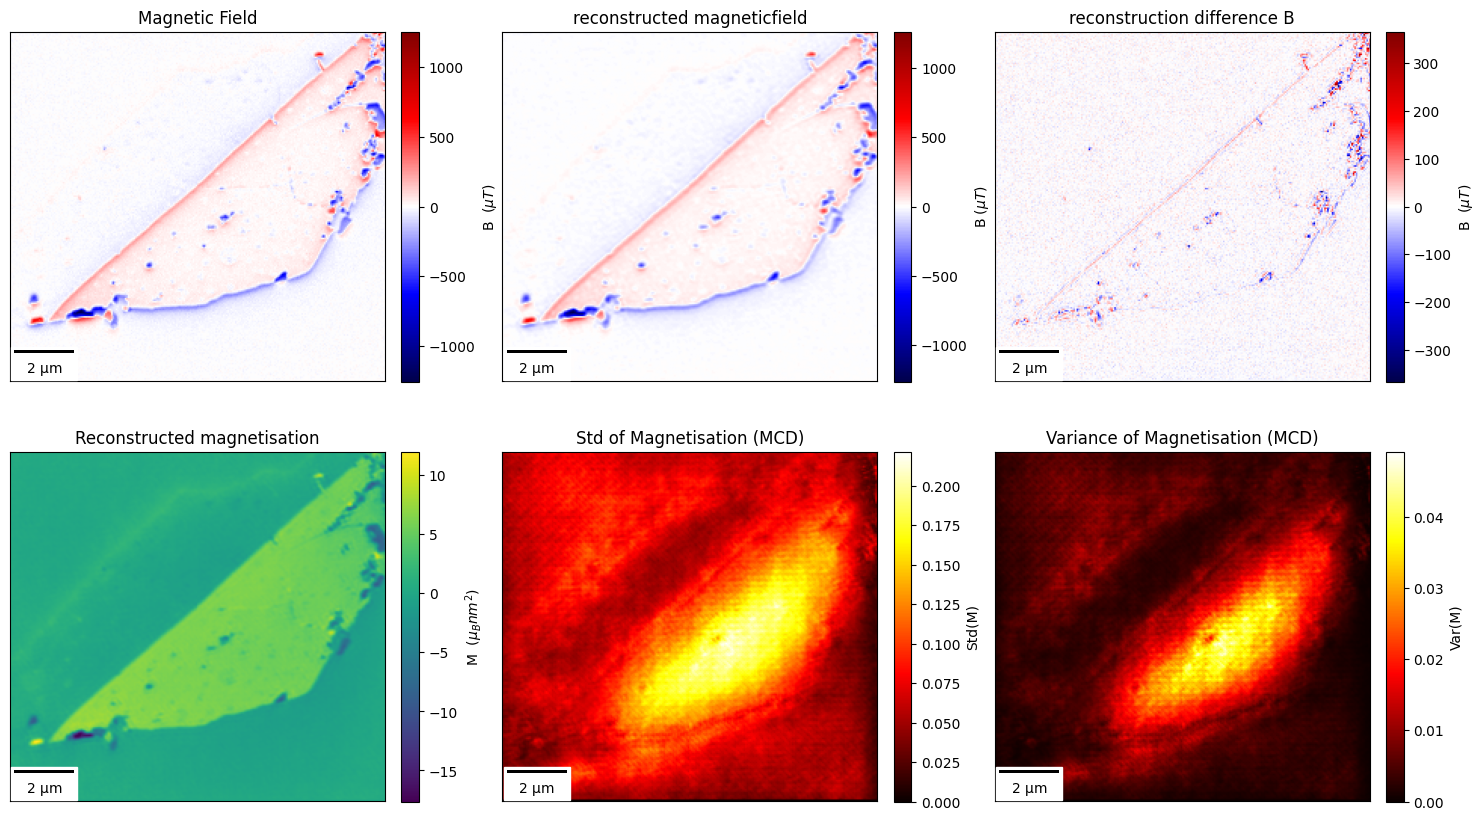

In [ ]:
Results = CNN_training.extract_results(plotResults = True)